In [1]:
!pip install sentencepiece pandas numpy matplotlib

▶ [Step 1] 코퍼스 준비 및 분석을 시작합니다.
- 총 데이터 개수: 500개
- 문장 최대 길이: 37
- 문장 최소 길이: 29


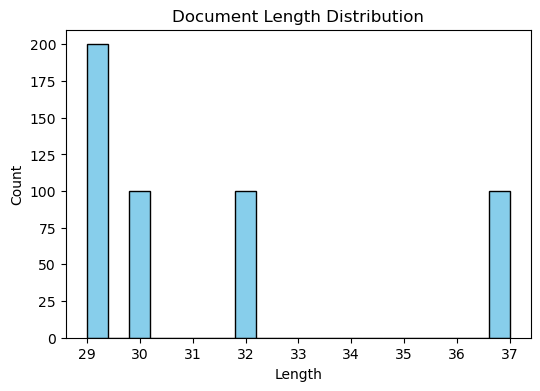


▶ [Step 2] 데이터 전처리를 진행합니다.
- 전처리 후 남은 고유 데이터 개수: 5개
- SentencePiece 학습용 코퍼스 파일 생성 완료: pipeline_corpus.txt

▶ [Step 3] SentencePiece 모델을 학습합니다.
- SentencePiece 학습 완료 (test_spm.model, test_spm.vocab 파일 생성됨)

▶ [Step 4] 토크나이저의 동작을 눈으로 확인합니다.

[원본 문장]: 토크나이저가 잘 동작하는지 눈으로 직접 확인해 봅시다!
[서브워드 분절]: ['▁', '토', '크', '나', '이', '저', '가', '▁', '잘', '▁', '동', '작', '하는', '지', '▁', '눈', '으', '로', '▁', '직', '접', '▁', '확', '인', '해', '▁', '봅', '시', '다', '!']
[정수 인코딩]: [3, 79, 19, 86, 7, 75, 44, 3, 73, 3, 34, 36, 11, 18, 3, 48, 9, 8, 3, 77, 76, 3, 24, 70, 20, 3, 60, 22, 4, 43]
[텍스트 복원]: 토크나이저가 잘 동작하는지 눈으로 직접 확인해 봅시다!
=> 💡 검증 완료: 텍스트가 정상적으로 인코딩 및 디코딩 되었습니다.

▶ [Step 5] 딥러닝 모델 입력을 위한 데이터 포맷팅을 확인합니다.
- 패딩 적용 전 길이: 30
- 패딩 적용 후 길이: 15
- 최종 모델 입력 형태(List/Tensor): [3, 79, 19, 86, 7, 75, 44, 3, 73, 3, 34, 36, 11, 18, 3]

✅ 전체 데이터 파이프라인 검증이 성공적으로 완료되었습니다!


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=pipeline_corpus.txt --model_prefix=test_spm --vocab_size=90 --model_type=unigram --character_coverage=1.0
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: pipeline_corpus.txt
  input_format: 
  model_prefix: test_spm
  model_type: UNIGRAM
  vocab_size: 90
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 

In [2]:
import pandas as pd
import numpy as np
import sentencepiece as spm
import matplotlib.pyplot as plt
import os

# ==========================================
# Step 1. 코퍼스 준비 및 분석 (Corpus Analysis)
# ==========================================
print("▶ [Step 1] 코퍼스 준비 및 분석을 시작합니다.")

# 실습용 가상 데이터 생성 (실제 환경에서는 CSV 등 로드)
raw_data = [
    "자연어 처리 모델을 학습하는 것은 매우 흥미롭습니다.",
    "SentencePiece는 단어장 크기를 효율적으로 관리해 줍니다.",
    "딥러닝 파이프라인의 흐름을 시각적으로 확인하는 실습입니다.",
    "데이터 전처리는 모델 성능에 지대한 영향을 미칩니다.",
    "토크나이저가 잘 동작하는지 눈으로 직접 확인해 봅시다!"
] * 100 # 분석을 위해 데이터 부풀리기

df = pd.DataFrame(raw_data, columns=['document'])

# 문장 길이 분석
df['length'] = df['document'].apply(len)
print(f"- 총 데이터 개수: {len(df)}개")
print(f"- 문장 최대 길이: {df['length'].max()}")
print(f"- 문장 최소 길이: {df['length'].min()}")

# 시각화: 문장 길이 분포 확인
plt.figure(figsize=(6, 4))
plt.hist(df['length'], bins=20, color='skyblue', edgecolor='black')
plt.title('Document Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

# ==========================================
# Step 2. 데이터 전처리 (Preprocessing)
# ==========================================
print("\n▶ [Step 2] 데이터 전처리를 진행합니다.")

# 예시: 너무 짧거나 긴 문장 필터링 및 중복 제거
df_clean = df.drop_duplicates(subset=['document'])
df_clean = df_clean[(df_clean['length'] >= 10) & (df_clean['length'] <= 100)]

print(f"- 전처리 후 남은 고유 데이터 개수: {len(df_clean)}개")

# 학습용 텍스트 파일 생성
corpus_file = 'pipeline_corpus.txt'
with open(corpus_file, 'w', encoding='utf-8') as f:
    for doc in df_clean['document']:
        f.write(doc + '\n')
print(f"- SentencePiece 학습용 코퍼스 파일 생성 완료: {corpus_file}")

# ==========================================
# Step 3. SentencePiece 모델 적용 및 학습 (SPM Training)
# ==========================================
print("\n▶ [Step 3] SentencePiece 모델을 학습합니다.")

# 💡 수정사항: 단어장 크기를 에러 메시지 상한선(92)보다 작은 90으로 조정
vocab_size = 90 

# Unigram 모델 학습
spm.SentencePieceTrainer.train(
    f'--input={corpus_file} --model_prefix=test_spm '
    f'--vocab_size={vocab_size} --model_type=unigram '
    f'--character_coverage=1.0'
)
print("- SentencePiece 학습 완료 (test_spm.model, test_spm.vocab 파일 생성됨)")

# ==========================================
# Step 4. 토크나이저 구현 및 동작 확인 (Tokenizer Action)
# ==========================================
print("\n▶ [Step 4] 토크나이저의 동작을 눈으로 확인합니다.")

# 학습된 모델 로드
sp = spm.SentencePieceProcessor()
sp.load('test_spm.model')

sample_text = "토크나이저가 잘 동작하는지 눈으로 직접 확인해 봅시다!"
print(f"\n[원본 문장]: {sample_text}")

# 1. 텍스트 -> 서브워드 조각(Pieces)
pieces = sp.encode_as_pieces(sample_text)
print(f"[서브워드 분절]: {pieces}")

# 2. 텍스트 -> 정수 인덱스(IDs)
ids = sp.encode_as_ids(sample_text)
print(f"[정수 인코딩]: {ids}")

# 3. 정수 인덱스 -> 텍스트 복원(Decode) 확인
decoded_text = sp.decode_ids(ids)
print(f"[텍스트 복원]: {decoded_text}")

# 복원 검증
if sample_text.replace(" ", "") == decoded_text.replace(" ", ""):
    print("=> 💡 검증 완료: 텍스트가 정상적으로 인코딩 및 디코딩 되었습니다.")

# ==========================================
# Step 5. 모델 입력용 텐서 포맷팅 (Tensor Formatting)
# ==========================================
print("\n▶ [Step 5] 딥러닝 모델 입력을 위한 데이터 포맷팅을 확인합니다.")

# 문장 길이를 맞춰주는 Padding 작업 시뮬레이션
max_seq_len = 15
padded_ids = ids[:max_seq_len] if len(ids) > max_seq_len else ids + [0] * (max_seq_len - len(ids))

print(f"- 패딩 적용 전 길이: {len(ids)}")
print(f"- 패딩 적용 후 길이: {len(padded_ids)}")
print(f"- 최종 모델 입력 형태(List/Tensor): {padded_ids}")
print("\n✅ 전체 데이터 파이프라인 검증이 성공적으로 완료되었습니다!")

# 임시 파일 삭제
os.remove(corpus_file)